In [85]:
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
df = pd.read_csv('/Users/atharva/Desktop/Coding/AIML/Weather_prediction/data/raw/weather_raw.csv')
df.head()

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,rain_sum,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,wind_direction_10m_dominant,sunshine_duration
0,2020-01-01,20.9,25.9,15.6,75,0.0,0.0,0,1013.7,13.2,350,37281.26
1,2020-01-02,21.9,26.7,17.7,77,0.0,0.0,10,1015.8,16.1,337,36992.17
2,2020-01-03,21.8,26.5,18.5,75,0.0,0.0,43,1015.2,23.5,348,36971.84
3,2020-01-04,21.6,25.9,18.3,67,0.0,0.0,32,1013.5,21.4,345,37488.60
4,2020-01-05,23.1,29.7,18.4,66,0.0,0.0,0,1012.7,16.8,30,37467.29


In [87]:
df.isnull().sum()

time                           0
temperature_2m_mean            0
temperature_2m_max             0
temperature_2m_min             0
relative_humidity_2m_mean      0
precipitation_sum              0
rain_sum                       0
cloud_cover_mean               0
pressure_msl_mean              0
wind_speed_10m_max             0
wind_direction_10m_dominant    0
sunshine_duration              0
dtype: int64

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         1827 non-null   str    
 1   temperature_2m_mean          1827 non-null   float64
 2   temperature_2m_max           1827 non-null   float64
 3   temperature_2m_min           1827 non-null   float64
 4   relative_humidity_2m_mean    1827 non-null   int64  
 5   precipitation_sum            1827 non-null   float64
 6   rain_sum                     1827 non-null   float64
 7   cloud_cover_mean             1827 non-null   int64  
 8   pressure_msl_mean            1827 non-null   float64
 9   wind_speed_10m_max           1827 non-null   float64
 10  wind_direction_10m_dominant  1827 non-null   int64  
 11  sunshine_duration            1827 non-null   float64
dtypes: float64(8), int64(3), str(1)
memory usage: 171.4 KB


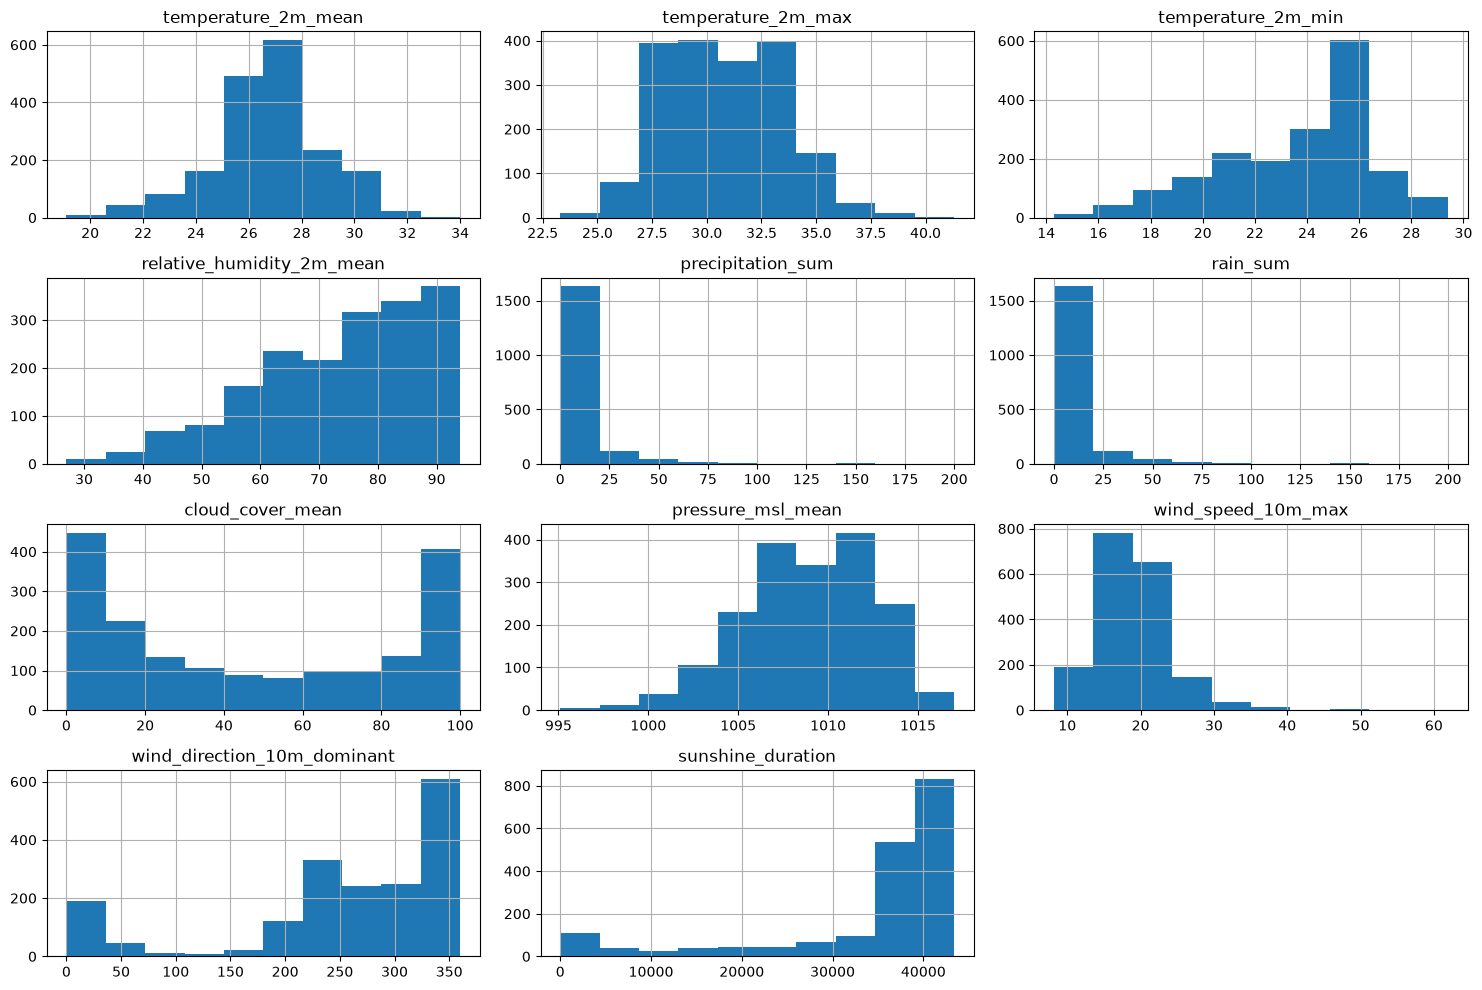

In [89]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

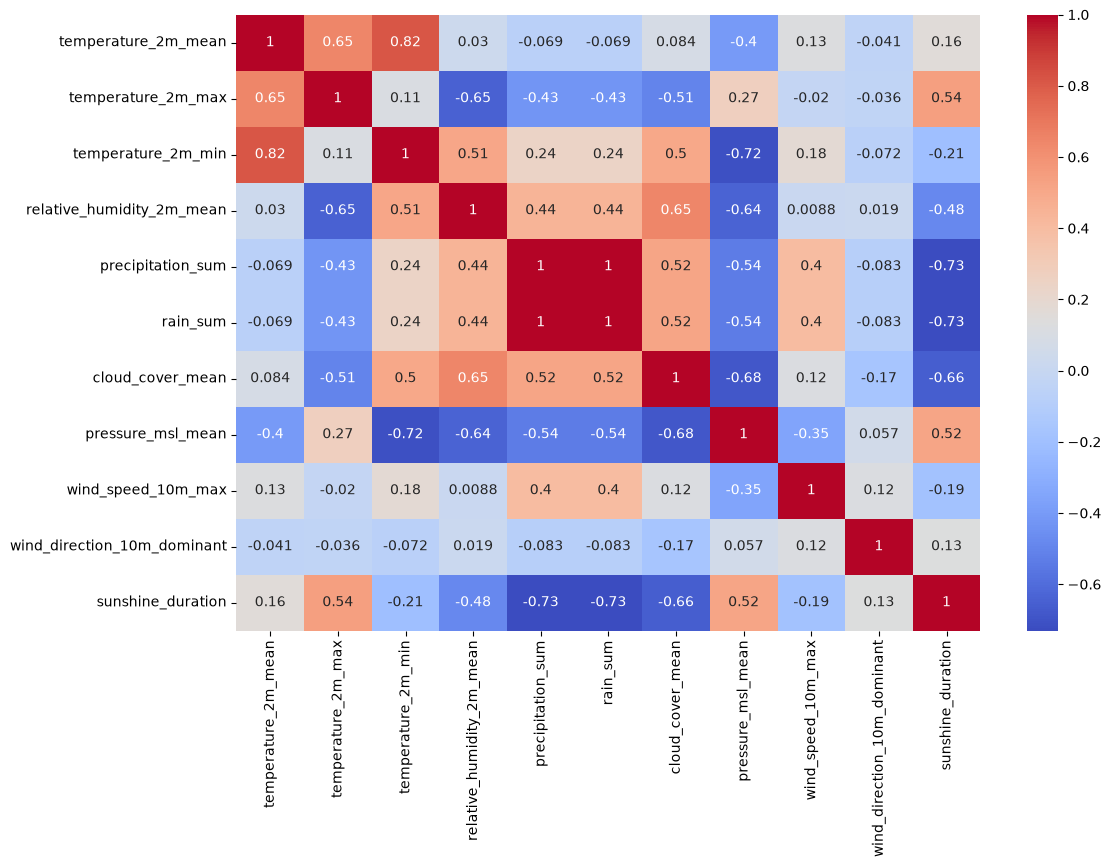

In [90]:
import seaborn as sns   

plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()


In [91]:
df["time"] = pd.to_datetime(df["time"])

In [92]:
df = df.sort_values("time").reset_index(drop=True)

In [93]:
df.head()

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,rain_sum,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,wind_direction_10m_dominant,sunshine_duration
0,2020-01-01,20.9,25.9,15.6,75,0.0,0.0,0,1013.7,13.2,350,37281.26
1,2020-01-02,21.9,26.7,17.7,77,0.0,0.0,10,1015.8,16.1,337,36992.17
2,2020-01-03,21.8,26.5,18.5,75,0.0,0.0,43,1015.2,23.5,348,36971.84
3,2020-01-04,21.6,25.9,18.3,67,0.0,0.0,32,1013.5,21.4,345,37488.60
4,2020-01-05,23.1,29.7,18.4,66,0.0,0.0,0,1012.7,16.8,30,37467.29


In [94]:
df[['rain_sum','time']].head(5)

,rain_sum,time
0,0.0,2020-01-01
1,0.0,2020-01-02
2,0.0,2020-01-03
3,0.0,2020-01-04
4,0.0,2020-01-05


In [95]:
df['tomorrow_rain'] = df['rain_sum'].shift(-1)
df['RainTomorrow'] = (df['tomorrow_rain']>0).astype(int)

In [96]:
df[['time','rain_sum','RainTomorrow','tomorrow_rain']].head()

,time,rain_sum,RainTomorrow,tomorrow_rain
0,2020-01-01,0.0,0,0.0
1,2020-01-02,0.0,0,0.0
2,2020-01-03,0.0,0,0.0
3,2020-01-04,0.0,0,0.0
4,2020-01-05,0.0,0,0.0


In [97]:
df[["time", "rain_sum", "tomorrow_rain", "RainTomorrow"]].tail(3)

,time,rain_sum,tomorrow_rain,RainTomorrow
1824,2024-12-29,0.0,0.0,0
1825,2024-12-30,0.0,0.0,0
1826,2024-12-31,0.0,NaN,0


In [98]:
df[["time", "rain_sum", "tomorrow_rain", "RainTomorrow"]].tail(3)

,time,rain_sum,tomorrow_rain,RainTomorrow
1824,2024-12-29,0.0,0.0,0
1825,2024-12-30,0.0,0.0,0
1826,2024-12-31,0.0,NaN,0


In [99]:
df = df.iloc[:-1].copy()
df = df.drop(columns=["tomorrow_rain"])

In [100]:
df[["time", "rain_sum", "RainTomorrow"]].tail(2)

,time,rain_sum,RainTomorrow
1824,2024-12-29,0.0,0
1825,2024-12-30,0.0,0


In [101]:
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.day_of_week
df[["time", "month", "day_of_week", "RainTomorrow"]].head(3)

,time,month,day_of_week,RainTomorrow
0,2020-01-01,1,2,0
1,2020-01-02,1,3,0
2,2020-01-03,1,4,0


In [103]:
features =[
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "cloud_cover_mean",
    "pressure_msl_mean",
    "wind_speed_10m_max",
    "wind_direction_10m_dominant",
    "sunshine_duration",
    "month",
    "day_of_week"
]

df['RainTomorrow'].value_counts()

RainTomorrow
0    1019
1     807
Name: count, dtype: int64